## Einlesen der Daten in ein DataFrame

In [14]:
import pandas as pd

# CSV einlesen und Timestamp parsen
df = pd.read_csv("apotheke_sales_filled.csv", parse_dates=["timestamp"])

# explizit in UTC interpretieren und dann nach Berlin konvertieren
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.set_index("timestamp").tz_convert("Europe/Berlin")

df


,count
timestamp,
2024-07-01 08:00:00+02:00,47
2024-07-01 08:30:00+02:00,47
2024-07-01 09:00:00+02:00,46
2024-07-01 09:30:00+02:00,42
2024-07-01 10:00:00+02:00,76
...,...
2025-07-31 15:30:00+02:00,32
2025-07-31 16:00:00+02:00,48
2025-07-31 16:30:00+02:00,68


Sehr gute Frage 🙌 – das wirkt auf den ersten Blick redundant, ist aber der **Trick**, mit dem man eine **Kreis- bzw. Zyklus-Information** ins Modell bringt.

---

### Problem bei zyklischen Variablen

Nehmen wir die **Stunde im Tag** als Zahl $0 … 23$:

* 23 Uhr und 0 Uhr sind in Wirklichkeit **direkt nebeneinander**.
* Als Zahl aber: $23$ und $0$ → sehr weit auseinander.
* Ein lineares Modell (oder auch ein neuronales Netz) würde dann fälschlich denken:
  „23 Uhr ist viel größer als 0 Uhr“ – obwohl sie fast das Gleiche bedeuten.

---

### Lösung: Projektion auf den Einheitskreis

Man stellt die Zeit **auf einem Kreis** dar, statt auf einer Linie:

* **sin(hour)** = Y-Koordinate
* **cos(hour)** = X-Koordinate

So wird **23 Uhr** und **0 Uhr** fast die gleichen Werte haben, weil sie auf dem Kreis **nebeneinanderliegen**.

👉 Beispiel:

| Stunde | Nur Zahl | sin(2π·hour/24) | cos(2π·hour/24) |
| ------ | -------- | --------------- | --------------- |
| 0      | 0        | 0.00            | 1.00            |
| 6      | 6        | 1.00            | 0.00            |
| 12     | 12       | 0.00            | -1.00           |
| 18     | 18       | -1.00           | 0.00            |
| 23     | 23       | -0.26           | 0.97            |

→ Man sieht: 23 Uhr und 0 Uhr liegen sehr dicht beieinander im (sin, cos)-Raum.

---

### Fazit

* **sin** und **cos** sind nötig, damit das Modell den **vollen Kreis** versteht.
* Mit nur einem Wert (z. B. nur `sin_hour`) gäbe es Ambiguitäten: 0 Uhr und 12 Uhr hätten beide den Wert 0.
* Durch das Paar `(sin, cos)` ist jede Stunde des Tages **eindeutig** repräsentiert.

---

👉 Soll ich dir mal eine **kleine Visualisierung in Python** machen (z. B. ein Kreisdiagramm mit den Stundenpunkten), damit man sofort sieht, warum `sin`+`cos` Sinn ergibt?


In [20]:
import numpy as np
import pandas as pd

# df: index = timestamp (tz-aware empfohlen), Spalte 'count'
df = df.sort_index()

# zyklische Features
hour = df.index.hour + df.index.minute/60.0
dow  = df.index.dayofweek
mon  = df.index.month

df["dayofweek"] = dow
df["mon"] = mon
df["hour"] = hour
df["sin_hour"] = np.sin(2*np.pi*hour/24); df["cos_hour"] = np.cos(2*np.pi*hour/24)
df["sin_dow"]  = np.sin(2*np.pi*dow/7);  df["cos_dow"]  = np.cos(2*np.pi*dow/7)
df["sin_mon"]  = np.sin(2*np.pi*mon/12); df["cos_mon"]  = np.cos(2*np.pi*mon/12)

feat_cols = ["sin_hour","cos_hour","sin_dow","cos_dow","sin_mon","cos_mon"]
X = df[feat_cols].astype("float32").values
y = df["count"].astype("float32").values.reshape(-1,1)
df


,count,sin_hour,cos_hour,sin_dow,cos_dow,sin_mon,cos_mon,dayofweek,mon,hour
timestamp,,,,,,,,,,
2024-07-01 08:00:00+02:00,47,0.866025,-0.500000,0.000000,1.000000,-0.5,-0.866025,0,7,8.0
2024-07-01 08:30:00+02:00,47,0.793353,-0.608761,0.000000,1.000000,-0.5,-0.866025,0,7,8.5
2024-07-01 09:00:00+02:00,46,0.707107,-0.707107,0.000000,1.000000,-0.5,-0.866025,0,7,9.0
2024-07-01 09:30:00+02:00,42,0.608761,-0.793353,0.000000,1.000000,-0.5,-0.866025,0,7,9.5
2024-07-01 10:00:00+02:00,76,0.500000,-0.866025,0.000000,1.000000,-0.5,-0.866025,0,7,10.0
...,...,...,...,...,...,...,...,...,...,...
2025-07-31 15:30:00+02:00,32,-0.793353,-0.608761,0.433884,-0.900969,-0.5,-0.866025,3,7,15.5
2025-07-31 16:00:00+02:00,48,-0.866025,-0.500000,0.433884,-0.900969,-0.5,-0.866025,3,7,16.0
2025-07-31 16:30:00+02:00,68,-0.923880,-0.382683,0.433884,-0.900969,-0.5,-0.866025,3,7,16.5


## Darstellen der Verkäufe im Zeitraum vom 1.7.2024 bis 31.7.2024 gruppiert nach Wochentagen

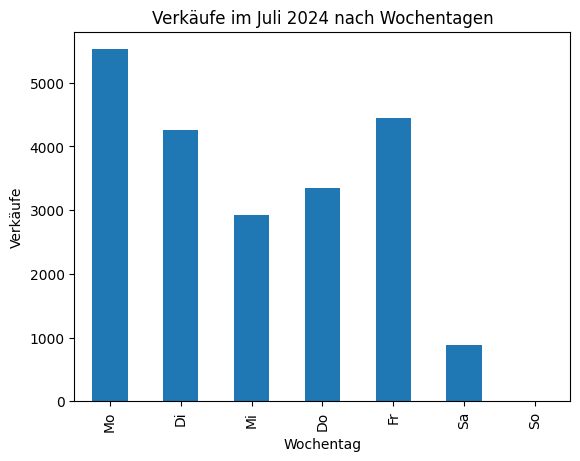

In [23]:
import matplotlib.pyplot as plt

# Verkäufe im Zeitraum vom 1.7.2024 bis 31.7.2024 gruppiert nach Wochentagen als Balkendiagramm
# Deutsche Kurzbezeichnungen für die Wochentage
weekday_labels = ["Mo", "Di", "Mi", "Do", "Fr", "Sa", "So"]

df_july = df["2024-07-01":"2024-07-31"]
# Gruppieren und Plotten
sales_by_day = df_july.groupby("dayofweek")["count"].sum().reindex(range(7), fill_value=0)
sales_by_day.index = weekday_labels
sales_by_day.plot(kind="bar", title="Verkäufe im Juli 2024 nach Wochentagen", xlabel="Wochentag", ylabel="Verkäufe")
plt.show()

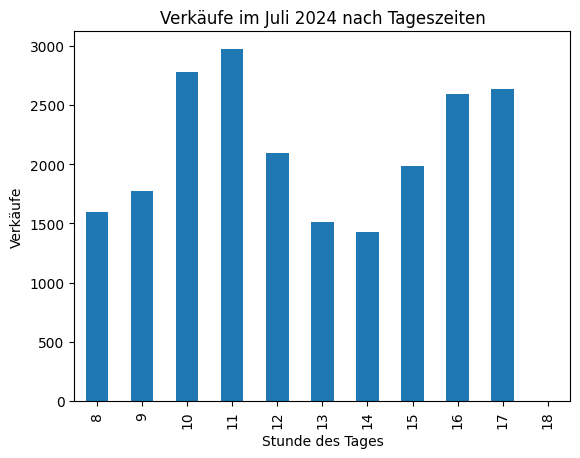

In [34]:
# Verkäufe im Zeitraum vom 1.7.2024 bis 31.7.2024 gruppiert nach Tageszeiten (nur 8:00 bis 18:00)

df_july = df["2024-07-01":"2024-07-31"]
july_data = df_july.between_time("08:00", "18:00")
july_data = july_data.copy()
july_data["hour"] = july_data.index.hour  # Stunde aus dem Index extrahieren
sales_by_hour = july_data.groupby("hour")["count"].sum()
sales_by_hour.plot(kind="bar")
plt.title("Verkäufe im Juli 2024 nach Tageszeiten")
plt.xlabel("Stunde des Tages")
plt.ylabel("Verkäufe")
plt.show()

C:\Users\jtutt\AppData\Local\Temp\ipykernel_39304\533487926.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  year_data["month"] = year_data.index.to_period("M").to_timestamp()


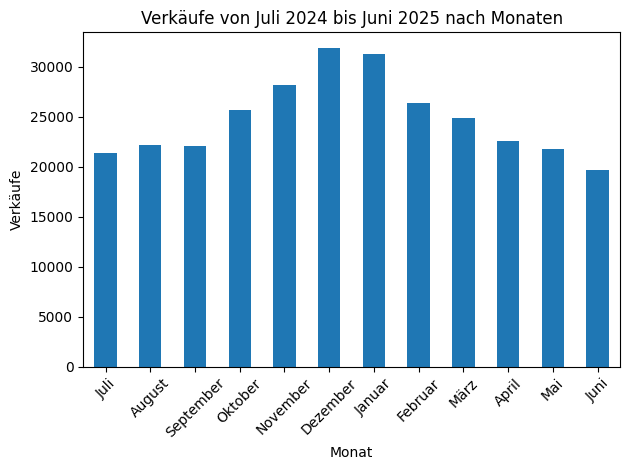

In [36]:
# Verkäufe vom 1.7.2024 bis 30.6.2025 gruppiert nach Monaten als Balkendiagramm
de_months = ["Januar", "Februar", "März", "April", "Mai", "Juni", "Juli", "August", "September", "Oktober", "November", "Dezember"]

year_data = df[(df.index >= "2024-07-01") & (df.index < "2025-07-01")].copy()
year_data["month"] = year_data.index.to_period("M").to_timestamp()
sales_by_month = year_data.groupby("month")["count"].sum()

# Index aufsteigend sortieren und Monatsnamen von Juli bis Juni zuweisen
months_july_to_june = de_months[6:] + de_months[:6]
sales_by_month = sales_by_month.sort_index()
sales_by_month.index = months_july_to_june

sales_by_month.plot(kind="bar")
plt.title("Verkäufe von Juli 2024 bis Juni 2025 nach Monaten")
plt.xlabel("Monat")
plt.ylabel("Verkäufe")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Saklieren der Daten

In [28]:
%pip install scikit-learn

from sklearn.preprocessing import StandardScaler
y_scaler = StandardScaler()
y_scaled = y_scaler.fit_transform(y).astype("float32")
y_scaled




Note: you may need to restart the kernel to use updated packages.


array([[1.1175058],
       [1.1175058],
       [1.0805163],
       ...,
       [1.8942853],
       [1.3394428],
       [1.2284744]], shape=(18980, 1), dtype=float32)

## Aufteilen in Trainings- und Testdaten

In [29]:
split = int(len(X)*0.8)
X_tr, X_va = X[:split], X[split:]
y_tr, y_va = y_scaled[:split], y_scaled[split:]


## Neuronales Modell definieren und trainieren

In [19]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Dense(32, activation="relu", input_shape=(X.shape[1],)),
    Dropout(0.1),                # optional
    Dense(16, activation="relu"),
    Dense(1)                     # linearer Output
])

model.compile(optimizer="adam", loss="mse")
es = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

history = model.fit(
    X_tr, y_tr,
    validation_data=(X_va, y_va),
    epochs=100, batch_size=32,
    shuffle=False, callbacks=[es], verbose=1
)
model.summary()


Epoch 1/100


c:\Users\jtutt\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


475/475 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.5132 - val_loss: 0.2224
Epoch 2/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3269 - val_loss: 0.1508
Epoch 3/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2551 - val_loss: 0.1213
Epoch 4/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.2010 - val_loss: 0.0897
Epoch 5/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1574 - val_loss: 0.0686
Epoch 6/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1302 - val_loss: 0.0537
Epoch 7/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1097 - val_loss: 0.0434
Epoch 8/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0942 - val_loss: 0.0389
Epoch 9/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0827 - val_loss: 0.0335
Epoch 10/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0731 - val_loss: 0.0301
Epoch 11/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0695 - val_loss: 0.0296
Epoch 12/100
475/475 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,309 (9.02 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,540 (6.02 KB)

## Vorhersagen mit dem Modell 

In [38]:
def make_time_features(ts: pd.Timestamp):
    hour = ts.hour + ts.minute/60.0
    dow  = ts.dayofweek
    mon  = ts.month
    return np.array([
        np.sin(2*np.pi*hour/24), np.cos(2*np.pi*hour/24),
        np.sin(2*np.pi*dow/7),  np.cos(2*np.pi*dow/7),
        np.sin(2*np.pi*mon/12), np.cos(2*np.pi*mon/12),
    ], dtype="float32").reshape(1,-1)

# Beispiel:
ts = pd.Timestamp("2026-09-05 17:00:00+01:00")  # gleiche TZ wie dein df
x_new = make_time_features(ts)
y_pred_scaled = model.predict(x_new, verbose=0)
y_pred = float(y_scaler.inverse_transform(y_pred_scaled)[0,0])  # zurückskalieren
print(f"Erwartete Verkäufe für {ts}: {round(y_pred)}")


Erwartete Verkäufe für 2026-09-05 17:00:00+01:00: -1
